## 1. Types of calculations AiiDAlab provides
AiiDAlab provides following resources for absorption studies:

## 2. Properties of the material:
Density ($g/cm^{3}$) - 0.576983

ASA ($A^{2}$) - 3964.65

POAV ($A^{3}$) - 13737.4

Porosity can be calculated as follows: 
$$\varepsilon = \frac{V_{\mathrm{POAV}}}{V_{\mathrm{cell}}}
= \frac{13737.4}{17726.2}
= 0.77498$$

So, the porosity is $ 77.50\%$


## 3. Henry coefficients

The computed Henry coefficients for $CO_2$ and $CH_4$ are 4.95118e-06 $\frac{mol}{kg\cdot Pa}$ and 1.12045e-06 $\frac{mol}{kg\cdot Pa}$, respectively.

## 4. Isotherms calculations

Change the plotting code it is disgusting

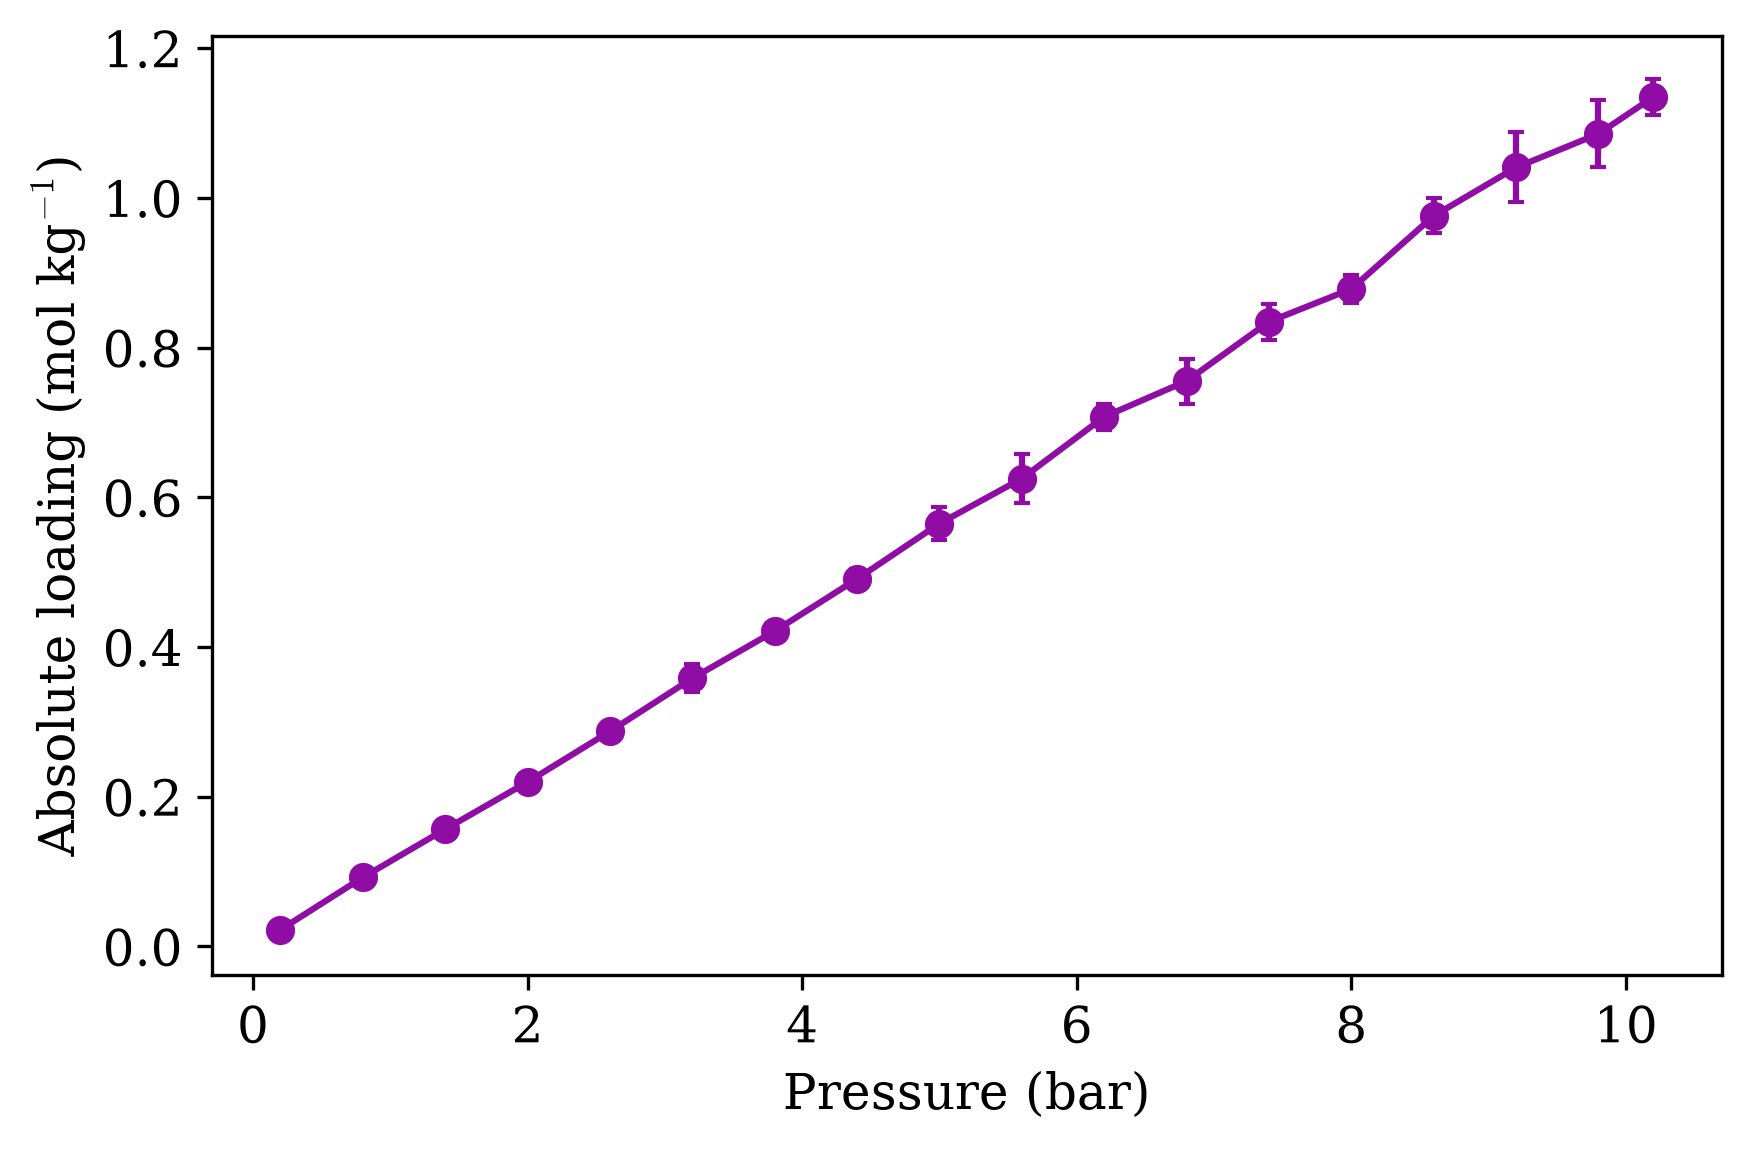

In [3]:
import ast
import csv
import matplotlib.pyplot as plt

with open("ch4_results.csv", newline="") as file:
    data = {row["Key"]: row["Value"] for row in csv.DictReader(file)}

iso = ast.literal_eval(data["isotherm"])
pressure = iso["pressure"]
loading = iso["loading_absolute_average"]

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 12,
})

fig, ax = plt.subplots(figsize=(6, 4), dpi=300)
ax.errorbar(
    iso["pressure"],
    iso["loading_absolute_average"],
    yerr=iso["loading_absolute_dev"],
    fmt="o-",
    color=plt.colormaps["plasma"](0.30),
    capsize=2,
)

ax.set(xlabel="Pressure (bar)", ylabel=r"Absolute loading (mol kg$^{-1}$)")
fig.tight_layout()
plt.show()

## 5. Binary-mixture isotherms using IAST

Conditions : $T = 300\,\mathrm{K}$, $y_{\mathrm{CO_2}}=0.40$ and $y_{\mathrm{CH_4}}=0.60$ (biogas composition).

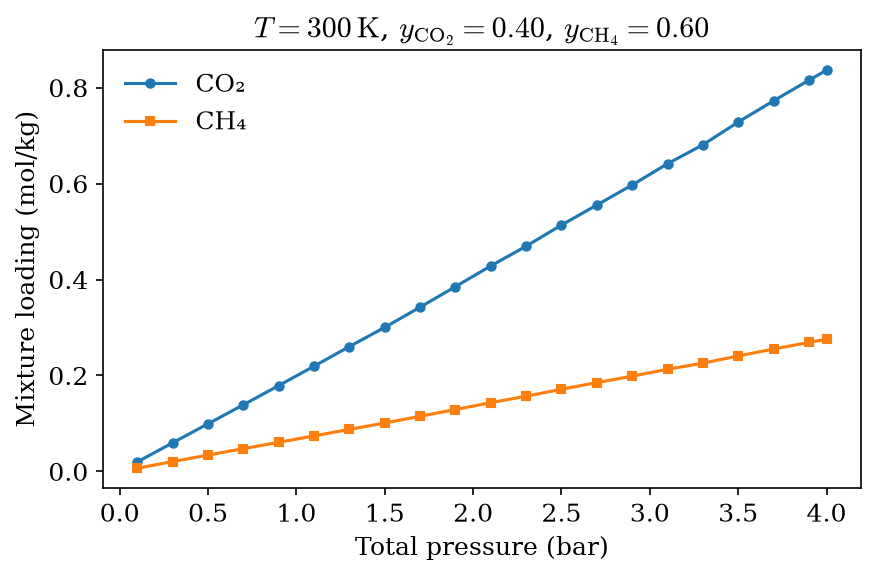

In [4]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyiast

isotherms = []
for filename in ["co2_results.csv", "ch4_results.csv"]:
    table = pd.read_csv(filename, index_col="Key")
    data = ast.literal_eval(table.loc["isotherm", "Value"]) #converts the dictionary stored as text into a python dictionary
    
    pure_gas = pd.DataFrame({"pressure": data["pressure"], "loading": data["loading_absolute_average"],})
    
    isotherm = pyiast.InterpolatorIsotherm(pure_gas, pressure_key="pressure", loading_key="loading") #calls the IAST intepolator which basically connects the puregas data points with straight lines
    isotherms.append(isotherm)

pressures = np.linspace(0.1, 3.9, 20)
pressures = np.append(pressures, 4.0) #add the last pressure point since the prevoius one ends with 3.9
y = np.array([0.40, 0.60]) #store the given gas fractions

co2_loadings = []
ch4_loadings = []
for pressure in pressures:
    partial_pressures = pressure * y
    co2_loading, ch4_loading = pyiast.iast(partial_pressures, isotherms) #call the IAST function which calculates the loadings based on the partial pressures and isotherms
    co2_loadings.append(co2_loading)
    ch4_loadings.append(ch4_loading)

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 12,
})

plt.figure(figsize=(6, 4), dpi=150)
plt.plot(pressures, co2_loadings, "o-", markersize=4, label="CO₂")
plt.plot(pressures, ch4_loadings, "s-", markersize=4, label="CH₄")
plt.xlabel("Total pressure (bar)")
plt.ylabel("Mixture loading (mol/kg)")
plt.title(r"$T = 300\,\mathrm{K}$, $y_{\mathrm{CO_2}} = 0.40$, $y_{\mathrm{CH_4}} = 0.60$")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()